Señales de cardiacas obtenidas por medio de un capnografo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [ ]:
#Comenzamos por ver la cantidad de archivos que contiene la base de datos
archivos = sorted(glob.glob('*.csv'))
print("Número de archivos encontrados:",len(archivos))

Número de archivos encontrados: 14


In [ ]:
#Revisamos el tamaño de la señal, y que todos los archivos tengan
#la misma duracion
longitudes=[]
for archivo in archivos:
  df=pd.read_csv(archivo)
  n=len(df)
  longitudes.append(n)
  print(f"{archivo:30s}  {n}")

Adan1_filtrada.csv              490700
Adan2_filtrada.csv              488800
Cor5_filtrada.csv               165312
Corazon1_3_filtrada_F.csv       804400
Corazon1_filtrada.csv           500000
Corazon2_filtrada.csv           500000
Corazon3_filtrada.csv           500000
CorazonAlex_filtrada.csv        488384
CorazonBeto-Oscar_filtrada.csv  389900
CorazonJorge_filtrada.csv       489700
CorazonSergio_filtrada.csv      486597
Vega1_filtrada.csv              535100
Vega2_filtrada.csv              505700
Vega3_filtrada.csv              490000


In [ ]:
#Revisamos que todas tengan la misma estructura
df=pd.read_csv(archivos[0])
print(df.head())
print(df.columns)
print(df.shape)

   Sample Number     Value
0              1  0.007166
1              2  0.007543
2              3  0.007764
3              4  0.008031
4              5  0.008126
Index(['Sample Number', 'Value'], dtype='object')
(490700, 2)


In [ ]:
#Ahora que ya vimos que efectivamente mantienen
#la estructura mas no la longitud, normalizamos los datos

#Abrimos un diccionario donde guadaremos los datos
senales={}
for archivo in archivos:
  df=pd.read_csv(archivo)
  y= df['Value'].values

  #Centramos en cero
  y=y-np.mean(y)

  #Normalizamos entre -1 y 1
  y= y/ np.max(np.abs(y))

  senales[archivo]=y

print('Se cargaron', len(senales),"señales" )


Se cargaron 14 señales


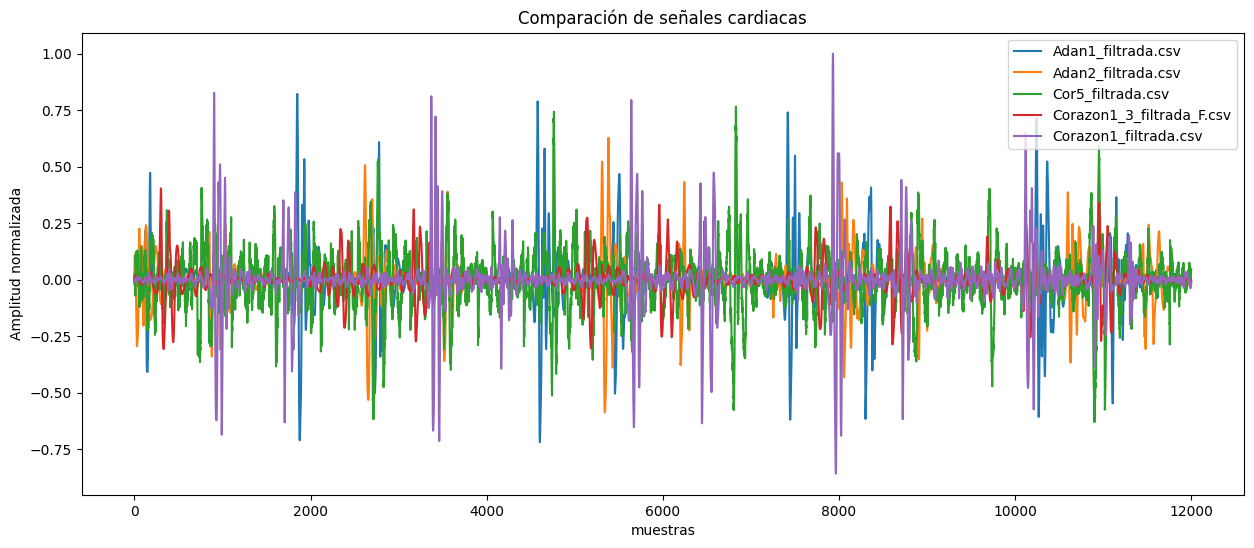

In [ ]:
#Graficamos para ver si los distintos sujetos tienen patrones
# similares o diferentes
plt.figure(figsize=(15,6))
for archivo in archivos[:5]:
  y= senales[archivo]
  plt.plot(y[:12000],label=archivo)
plt.xlabel('muestras')
plt.ylabel('Amplitud normalizada')
plt.title("Comparación de señales cardiacas")
plt.legend()
plt.show()




In [ ]:
#Vamos a construir una tabla para entender mejor esta base de datos
resumen=[]
for archivo in archivos:
  y= senales[archivo]
  media=np.mean(y)
  std=np.std(y)
  minimo=np.min(y)
  maximo=np.max(y)

  energia=np.sum(y**2)
  rms=np.sqrt(np.mean(y**2))
  resumen.append([archivo,media,std,minimo,maximo,energia,rms])
resumen=pd.DataFrame(resumen,columns=['archivo','media','std','minimo','maximo','energia','rms'])
resumen


,archivo,media,std,minimo,maximo,energia,rms
0,Adan1_filtrada.csv,8.201668e-20,0.065588,-0.869565,1.000000,2110.862085,0.065588
1,Adan2_filtrada.csv,-5.278556e-19,0.107444,-0.753700,1.000000,5642.765345,0.107444
2,Cor5_filtrada.csv,1.711218e-18,0.097043,-0.963178,1.000000,1556.804189,0.097043
3,Corazon1_3_filtrada_F.csv,-7.210101e-19,0.063455,-0.909070,1.000000,3238.966781,0.063455
4,Corazon1_filtrada.csv,7.676082e-19,0.102950,-0.858277,1.000000,5299.311864,0.102950
5,Corazon2_filtrada.csv,-7.309708e-19,0.111583,-0.903459,1.000000,6225.389860,0.111583
6,Corazon3_filtrada.csv,-5.968004e-19,0.080745,-0.935222,1.000000,3259.855364,0.080745
7,CorazonAlex_filtrada.csv,4.591982e-19,0.116874,-1.000000,0.895488,6671.107185,0.116874
8,CorazonBeto-Oscar_filtrada.csv,5.935611e-20,0.020506,-1.000000,0.787953,163.952452,0.020506
9,CorazonJorge_filtrada.csv,-8.275095e-19,0.100360,-1.000000,0.963316,4932.316134,0.100360


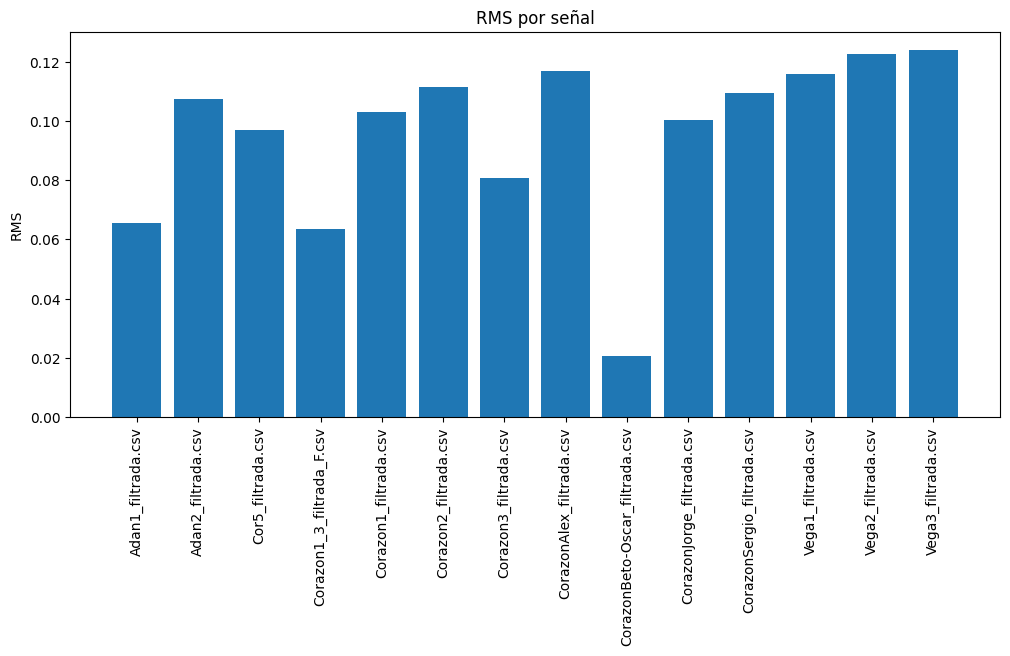

In [ ]:
plt.figure(figsize=(12,5))

plt.bar(resumen["archivo"], resumen["rms"])

plt.xticks(rotation=90)

plt.ylabel("RMS")

plt.title("RMS por señal")

plt.show()

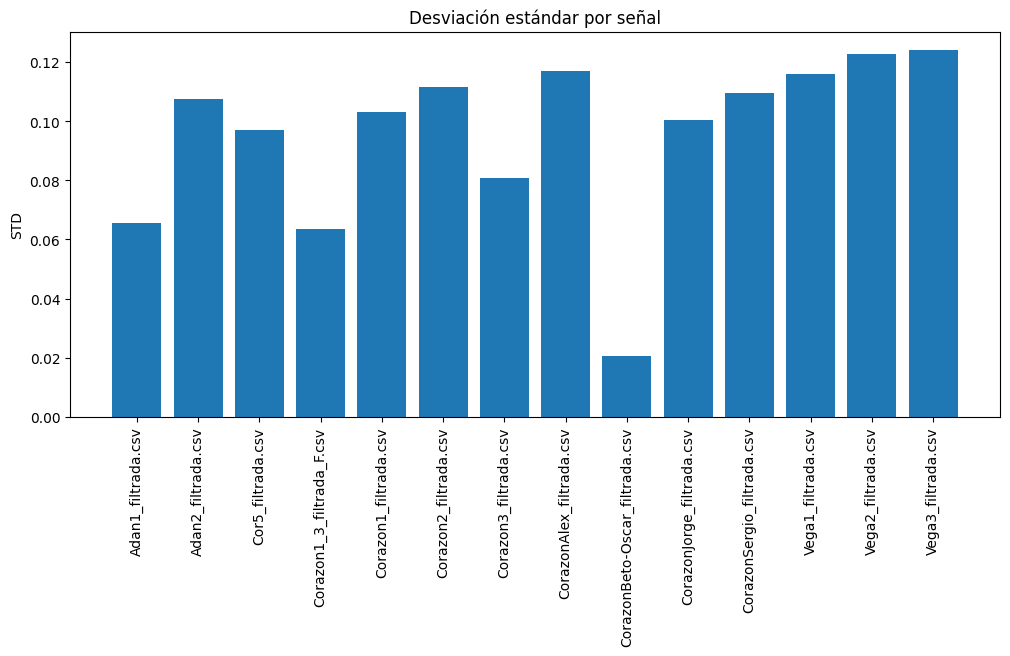

In [ ]:
plt.figure(figsize=(12,5))

plt.bar(resumen["archivo"], resumen["std"])

plt.xticks(rotation=90)

plt.ylabel("STD")

plt.title("Desviación estándar por señal")

plt.show()

In [ ]:
# Construimos las ventanas centradas en picos
from scipy.signal import find_peaks

fs = 1000
tam_ventana = int(0.6 * fs)
mitad = tam_ventana // 2

ventanas = []
etiquetas = []
posiciones_picos = []

#Estas variables nos daran iformacion temporal del ritmo cardiaco lo cual no beneficiara para saber si hay diferencia entre los paciente en la toma de datos
rr_previos=[]
rr_siguientes=[]
fc_local=[]

for archivo in archivos:

    y = senales[archivo]

    picos, propiedades = find_peaks(
        np.abs(y),
        height=0.1,
        distance=int(0.3 * fs)
    )
    for j, pico in enumerate(picos):
        inicio = pico - mitad
        fin = pico + mitad

        if inicio >= 0 and fin <= len(y):

            ventana = y[inicio:fin]

            ventanas.append(ventana)
            etiquetas.append(archivo)
            posiciones_picos.append(pico)
            if j > 0:
                rr_prev=pico - picos[j-1]
            else:
              rr_prev = np.nan

            if j < len(picos) - 1:
                rr_next=picos[j+1] - pico
            else:
              rr_next = np.nan

            rr_previos.append(rr_prev)
            rr_siguientes.append(rr_next)
            rr_local=np.mean([rr_prev,rr_next])

            if np.isnan(rr_local):
              fc=np.nan
            else:
              fc=60000/rr_local
            fc_local.append(fc)


ventanas = np.array(ventanas)
etiquetas = np.array(etiquetas)
posiciones_picos = np.array(posiciones_picos)

rr_previos=np.array(rr_previos)
rr_siguientes=np.array(rr_siguientes)
fc_local=np.array(fc_local)

print("Ventanas:", ventanas.shape)
print("Etiquetas:", etiquetas.shape)
print("Posiciones de picos:", posiciones_picos.shape)
print("FC local:", fc_local.shape)

print("Archivos únicos:")
print(np.unique(etiquetas))

print("Número de archivos únicos:", len(np.unique(etiquetas)))

Ventanas: (5999, 600)
Etiquetas: (5999,)
Posiciones de picos: (5999,)
FC local: (5999,)
Archivos únicos:
['Adan1_filtrada.csv' 'Adan2_filtrada.csv' 'Cor5_filtrada.csv'
 'Corazon1_3_filtrada_F.csv' 'Corazon1_filtrada.csv'
 'Corazon2_filtrada.csv' 'Corazon3_filtrada.csv'
 'CorazonAlex_filtrada.csv' 'CorazonBeto-Oscar_filtrada.csv'
 'CorazonJorge_filtrada.csv' 'CorazonSergio_filtrada.csv'
 'Vega1_filtrada.csv' 'Vega2_filtrada.csv' 'Vega3_filtrada.csv']
Número de archivos únicos: 14


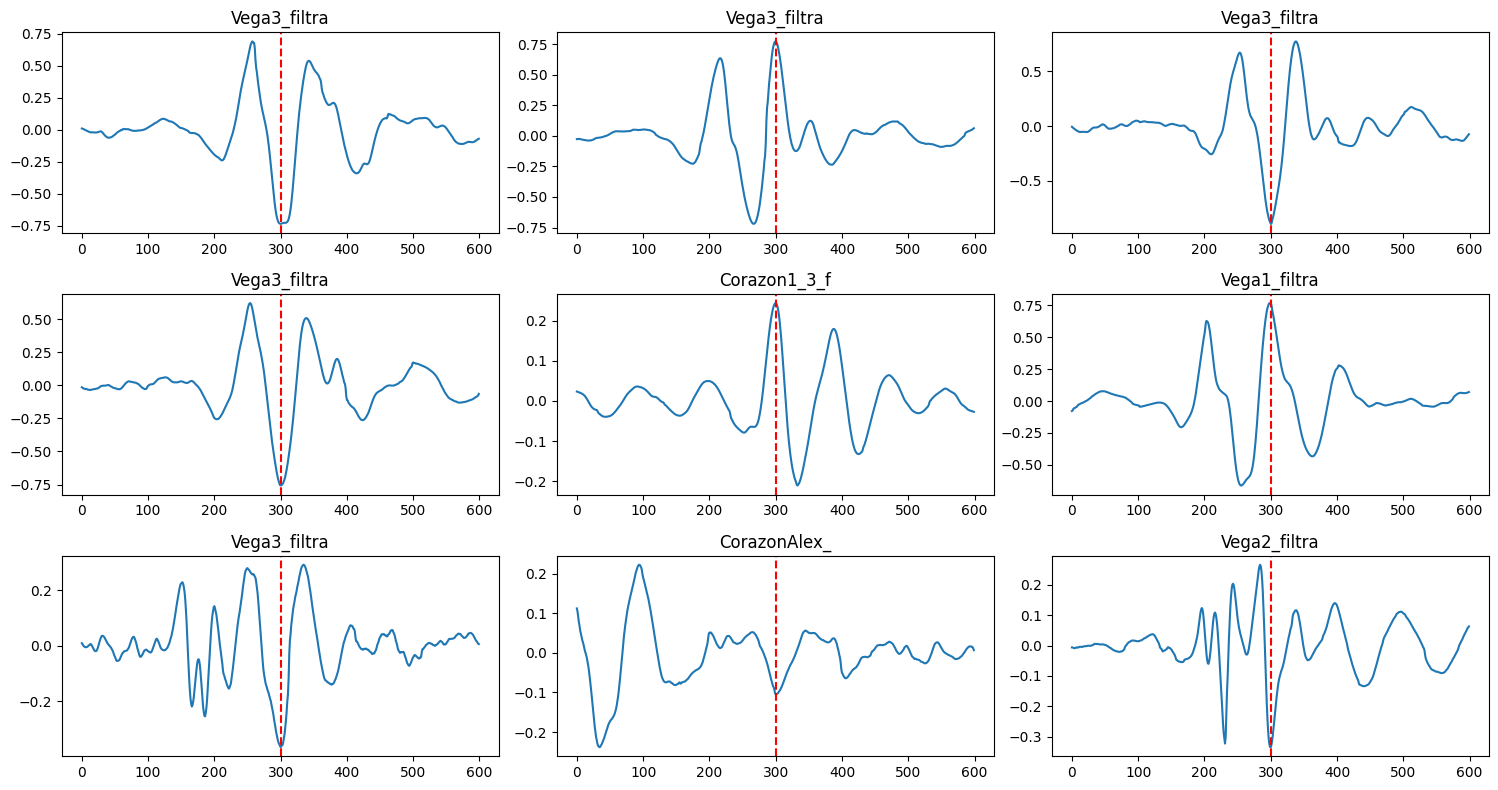

In [ ]:
# Revisamos algunas ventanas detectadas

plt.figure(figsize=(15,8))

indices = np.random.choice(len(ventanas), 9, replace=False)

for k, i in enumerate(indices):
    plt.subplot(3,3,k+1)
    plt.plot(ventanas[i])
    plt.axvline(x=mitad, color="red", linestyle="--")
    plt.title(etiquetas[i][:12])

plt.tight_layout()
plt.show()

In [ ]:
#Ahora vamos a extraer caracteristicas por ventana,
#a cada ventana se le calculan caracteristicas estadisticas para  reducir
# la dimension de los datos.
caracteristicas = []

for i, ventana in enumerate(ventanas):

    media = np.mean(ventana)
    std = np.std(ventana)
    rms = np.sqrt(np.mean(ventana**2))
    energia = np.sum(ventana**2)
    maximo = np.max(ventana)
    minimo = np.min(ventana)
    pico_pico = maximo - minimo

    pos_maximo = np.argmax(ventana)
    pos_minimo = np.argmin(ventana)

    ancho = np.abs(pos_maximo - pos_minimo)

    inicio_central = mitad - 100
    fin_central = mitad + 100

    energia_central = np.sum(ventana[inicio_central:fin_central]**2)

    if energia > 0:
        fraccion_central = energia_central / energia
    else:
        fraccion_central = 0

    if rms > 0:
        factor_cresta = np.max(np.abs(ventana)) / rms
    else:
        factor_cresta = 0

    caracteristicas.append([
        media,
        std,
        rms,
        energia,
        maximo,
        minimo,
        pico_pico,
        ancho,
        fraccion_central,
        factor_cresta,
        rr_previos[i],
        rr_siguientes[i],
        fc_local[i]
    ])

X = np.array(caracteristicas)

print("Matriz X:", X.shape)



Matriz X: (5999, 13)


In [ ]:
#Rellenamos Nan
for j in range(X.shape[1]):
  columna=X[:,j]
  columna[np.isnan(columna)]=np.nanmean(columna)
  X[:,j]=columna
print("NaN restantes:", np.isnan(X).sum())

print("std rr_previos:", np.std(X[:,10]))
print("std rr_siguientes:", np.std(X[:,11]))
print("std fc_local:", np.std(X[:,12]))


NaN restantes: 0
std rr_previos: 745.0146167448663
std rr_siguientes: 755.0731479418519
std fc_local: 35.19133998751375


In [ ]:
#Veamos la tabla ya con los datos
df_caracteristicas = pd.DataFrame(X, columns=[
    'media',
    'std',
    'rms',
    'energia',
    'maximo',
    'minimo',
    'pico_pico',
    'ancho',
    'fraccion_central',
    'factor_cresta',
    'rr_previos',
    'rr_siguientes',
    'fc_local'
])


df_caracteristicas['archivo'] = etiquetas
df_caracteristicas.head()

,media,std,rms,energia,maximo,minimo,pico_pico,ancho,fraccion_central,factor_cresta,rr_previos,rr_siguientes,fc_local,archivo
0,0.000233,0.214460,0.214460,27.595846,0.822082,-0.710550,1.532632,28.0,0.889347,3.833267,1670.0,929.0,46.171604,Adan1_filtrada.csv
1,-0.001056,0.150623,0.150627,13.613027,0.608995,-0.502002,1.110997,48.0,0.925151,4.043077,929.0,1801.0,43.956044,Adan1_filtrada.csv
2,-0.000231,0.207293,0.207293,25.782314,0.788878,-0.718378,1.507256,25.0,0.869950,3.805610,1801.0,878.0,44.792833,Adan1_filtrada.csv
3,0.003024,0.154179,0.154208,14.268152,0.467850,-0.504382,0.972232,49.0,0.820555,3.270777,878.0,1962.0,42.253521,Adan1_filtrada.csv
4,0.000584,0.191571,0.191572,22.019887,0.740181,-0.619312,1.359494,27.0,0.831533,3.863725,1962.0,882.0,42.194093,Adan1_filtrada.csv


In [ ]:
for col in df_caracteristicas.columns[:-1]:  # quitamos archivo

    print(
        col,
        "std =",
        df_caracteristicas[col].std()
    )

media std = 0.003406554584606962
std std = 0.0583001634714858
rms std = 0.058299616958081765
energia std = 10.029342221829568
maximo std = 0.2084588101418222
minimo std = 0.19925587813652967
pico_pico std = 0.3809980746382973
ancho std = 52.492645970359504
fraccion_central std = 0.25073757443189953
factor_cresta std = 0.7705684459176119
rr_previos std = 745.0767194096462
rr_siguientes std = 755.1360890621172
fc_local std = 35.194273454779065


In [ ]:
df_caracteristicas.describe()

,media,std,rms,energia,maximo,minimo,pico_pico,ancho,fraccion_central,factor_cresta,rr_previos,rr_siguientes,fc_local
count,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000,5999.000000
mean,0.000094,0.128805,0.128851,12.000459,0.419439,-0.428903,0.848343,52.957826,0.709045,3.782011,1133.260601,1134.939389,65.135435
std,0.003407,0.058300,0.058300,10.029342,0.208459,0.199256,0.380998,52.492646,0.250738,0.770568,745.076719,755.136089,35.194273
min,-0.015285,0.017283,0.017284,0.179235,0.056965,-1.000000,0.161778,3.000000,0.028742,2.110965,300.000000,300.000000,7.621467
25%,-0.000937,0.088349,0.088401,4.688853,0.256610,-0.569976,0.553068,26.000000,0.593831,3.192801,603.000000,603.000000,44.859813
50%,-0.000040,0.123399,0.123667,9.176189,0.390365,-0.404668,0.826213,37.000000,0.804314,3.673440,904.000000,904.000000,49.916805
75%,0.000683,0.163624,0.163667,16.072083,0.584163,-0.280183,1.147866,50.000000,0.900444,4.249162,1637.000000,1637.000000,65.135435
max,0.023558,0.342044,0.342053,70.200020,1.000000,-0.042395,1.963178,599.000000,0.994434,10.883702,12907.000000,12907.000000,199.335548


PCA

In [ ]:
#Todavia estamos tratando de conocer los datos,
#asi que utilizaremos un PCA para  ver si las caracteristicas que
#construimos si distinguen señales, esto nos ayudara a
#construir el modelo y buscar el mejor ajuste despues
# Matriz de características
# X ya tiene forma (7807, 7)

print("Forma original de X:", X.shape)
print("Primeras filas:")
print(X[:5])

#Iniciamos estandarizando
media_x=np.mean(X,axis=0)
std_x=np.std(X,axis=0)
X_norm=(X-media_x)/std_x

print(X_norm.shape)
print("NaN:", np.isnan(X_norm).sum())
print("Inf:", np.isinf(X_norm).sum())


Forma original de X: (5999, 13)
Primeras filas:
[[ 2.33076960e-04  2.14459838e-01  2.14459965e-01  2.75958459e+01
   8.22082369e-01 -7.10549539e-01  1.53263191e+00  2.80000000e+01
   8.89346572e-01  3.83326730e+00  1.67000000e+03  9.29000000e+02
   4.61716045e+01]
 [-1.05583863e-03  1.50622918e-01  1.50626619e-01  1.36130270e+01
   6.08994952e-01 -5.02002028e-01  1.11099698e+00  4.80000000e+01
   9.25150759e-01  4.04307655e+00  9.29000000e+02  1.80100000e+03
   4.39560440e+01]
 [-2.30639399e-04  2.07293198e-01  2.07293326e-01  2.57823138e+01
   7.88877650e-01 -7.18378156e-01  1.50725581e+00  2.50000000e+01
   8.69950395e-01  3.80561046e+00  1.80100000e+03  8.78000000e+02
   4.47928331e+01]
 [ 3.02387616e-03  1.54178821e-01  1.54208471e-01  1.42681515e+01
   4.67850105e-01 -5.04381545e-01  9.72231650e-01  4.90000000e+01
   8.20554615e-01  3.27077716e+00  8.78000000e+02  1.96200000e+03
   4.22535211e+01]
 [ 5.83543888e-04  1.91571062e-01  1.91571950e-01  2.20198873e+01
   7.40181392e-01 

In [ ]:
#Ahora aplicamos la funcion de la libreria aklearn
from sklearn.decomposition import PCA
pca=PCA()
PC=pca.fit_transform(X_norm)

print("Forma de PC:",PC.shape)
print('Varianza explicada:')
print(pca.explained_variance_ratio_)

print('Varianza explicada acumulada:')
print(np.cumsum(pca.explained_variance_ratio_))


Forma de PC: (5999, 13)
Varianza explicada:
[4.55438270e-01 1.92264231e-01 1.00182755e-01 6.62696346e-02
 6.23242188e-02 5.76873800e-02 2.82397247e-02 1.56670543e-02
 1.43407825e-02 6.36489171e-03 1.22095372e-03 1.04281830e-07
 1.67189461e-18]
Varianza explicada acumulada:
[0.45543827 0.6477025  0.74788526 0.81415489 0.87647911 0.93416649
 0.96240621 0.97807327 0.99241405 0.99877894 0.9999999  1.
 1.        ]


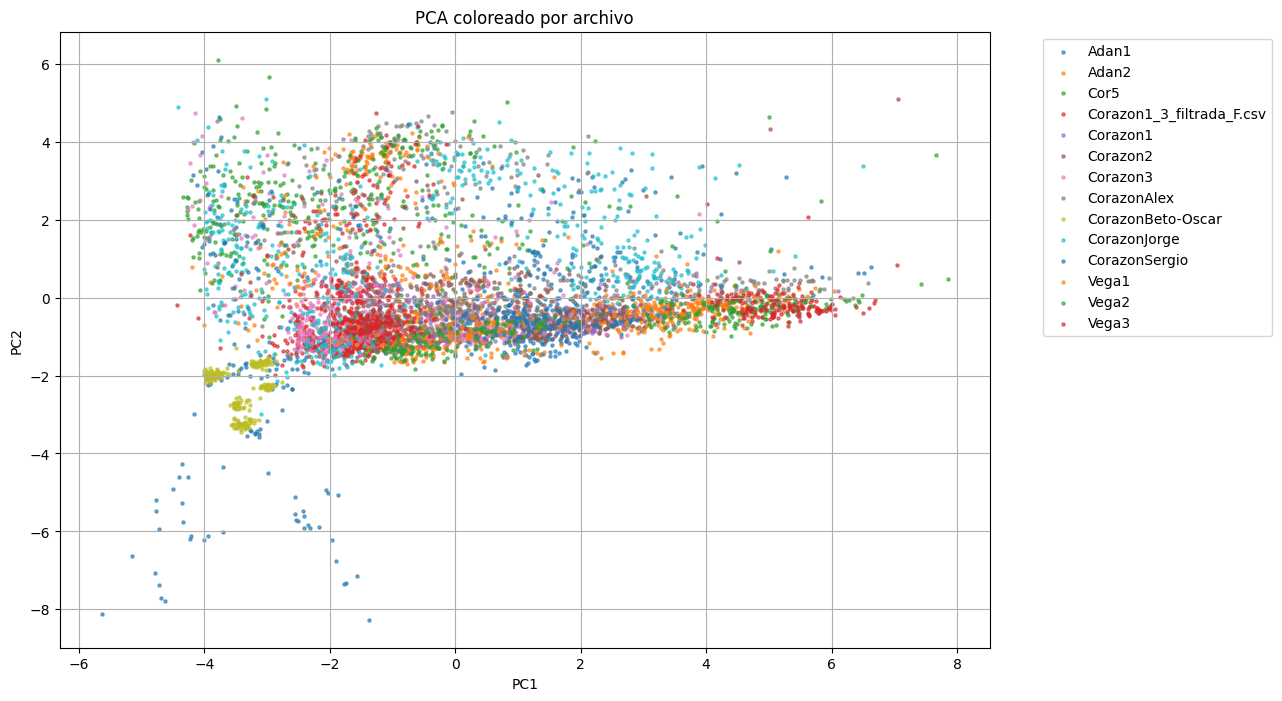

In [ ]:
#Graficamos para ver como se ve nuestro PCA
plt.figure(figsize=(12,8))

for archivo in archivos:

    mask = etiquetas == archivo

    plt.scatter(
        PC[mask,0],
        PC[mask,1],
        s=5,
        alpha=0.6,
        label=archivo.replace("_filtrada.csv","")
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA coloreado por archivo")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(True)
plt.show()

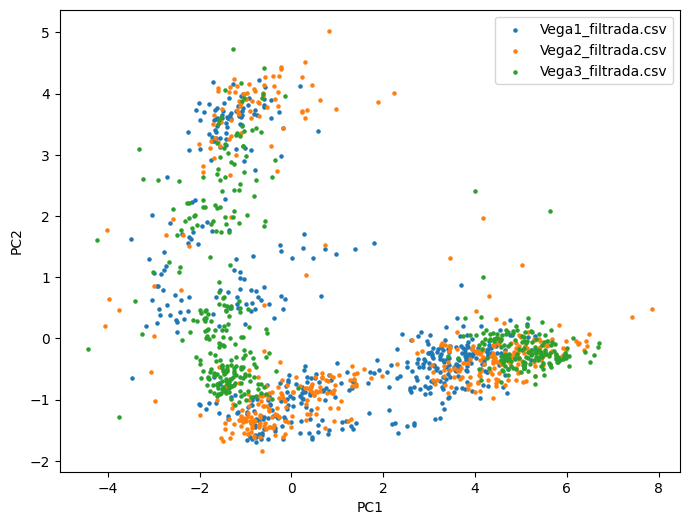

In [ ]:
#La mayoria de los pacientes se mantienen en una sola region o por lo menos su datos
#tienden en agruparce, pero podemos ver que el paciente vega presenta un patron inusual
#donde se divide en dos secciones alta y baja, por ello lo graficamos de manera individual,
#Nos interesa particularmente porque vega se durmio durante la medición


plt.figure(figsize=(8,6))

for archivo in ["Vega1_filtrada.csv",
                "Vega2_filtrada.csv",
                "Vega3_filtrada.csv"]:

    mask = etiquetas == archivo

    plt.scatter(
        PC[mask,0],
        PC[mask,1],
        s=5,
        label=archivo
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [ ]:

#Veamos a que corresponde cada componente  en la grafica de PCA, para ver que componente nos arroja
#algo interesante sobre estre paciente

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(X.shape[1])],
    index=[
        "media",
        "std",
        "rms",
        "energia",
        "maximo",
        "minimo",
        "pico_pico",
        "ancho",
        "fraccion_central",
        "factor_cresta",
        "rr_previos",
        "rr_siguientes",
        "fc_local"
    ]
)

print(loadings[["PC1","PC2"]])

                       PC1       PC2
media            -0.099040  0.231611
std               0.402079  0.092240
rms               0.401982  0.093120
energia           0.394653  0.066635
maximo            0.370282  0.089997
minimo           -0.375448 -0.003321
pico_pico         0.398949  0.050977
ancho            -0.077702  0.274290
fraccion_central  0.135366 -0.507274
factor_cresta    -0.047619 -0.116207
rr_previos        0.154423 -0.342045
rr_siguientes    -0.129890 -0.380669
fc_local         -0.081279  0.553224


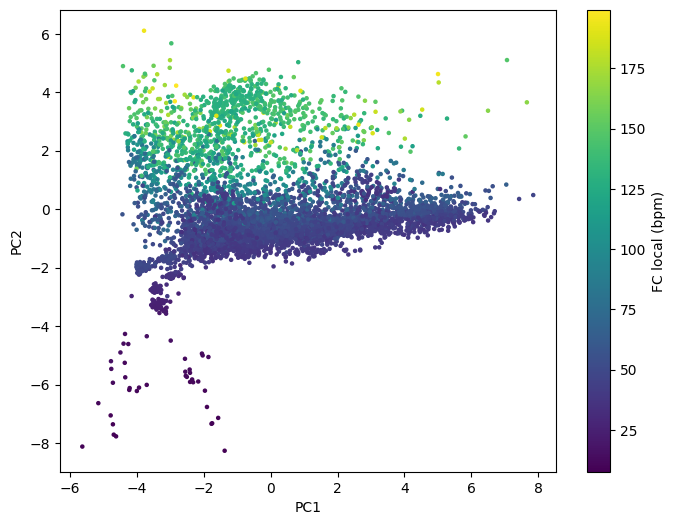

In [ ]:
#En los datos anteriores podemos ver una relacion muy interesante, tenemos
#que para FC alta hay rr corto, para FCbaja hay rr largo. La primera componente
#principal esta asociada a cafracteristicas morfologicas del latido, tales como
#RMS, energia y la amplitud pico a pico. La segunda componentestá dominada por características temporales, particularmente la frecuencia cardíaca local y los intervalos RR.
#Esto indica que el PCA separa tanto diferencias en la forma de los latidos como variaciones en la dinámica cardíaca.
plt.figure(figsize=(8,6))
plt.scatter(
    PC[:,0],
    PC[:,1],
    c=fc_local,
    cmap='viridis',
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="FC local (bpm)")
plt.show()

In [ ]:
for archivo in archivos:

    mask = etiquetas == archivo

    print(
        archivo,
        np.mean(fc_local[mask])
    )

Adan1_filtrada.csv 49.002336193034715
Adan2_filtrada.csv 52.57870442534023
Cor5_filtrada.csv nan
Corazon1_3_filtrada_F.csv nan
Corazon1_filtrada.csv nan
Corazon2_filtrada.csv nan
Corazon3_filtrada.csv nan
CorazonAlex_filtrada.csv nan
CorazonBeto-Oscar_filtrada.csv nan
CorazonJorge_filtrada.csv nan
CorazonSergio_filtrada.csv nan
Vega1_filtrada.csv nan
Vega2_filtrada.csv nan
Vega3_filtrada.csv nan


El PCA permitió verificar que las características extraídas de las señales cardíacas contienen información suficiente para distinguir diferentes tipos de eventos. La aparición de agrupamientos en el espacio de componentes principales indica que existen diferencias en la forma y propiedades temporales de los latidos registrados.Entonces lo que sigue es identifiacar cada evento, es decir que identifique a quien pertence el latido el saber que s vega o no nos proda mayudar a despues diferenciar etos patrones cuando el paciente entre en estado de reposo

Red neuronal

In [ ]:
#Reutilizamos la logica de perros y gatos, enonces
#hacemos algo com Vega=1 y No Vega=0

Y=[]
for e in etiquetas:
  if 'Vega' in e:
    Y.append(1)
  else:
    Y.append(0)
Y=np.array(Y)
print("Forma Y:", Y.shape)
print("Vega:", np.sum(Y==1))
print("No Vega:", np.sum(Y==0))

Forma Y: (5999,)
Vega: 1342
No Vega: 4657


In [ ]:
#Ahora preparamos X y Y para la red
X_red=X_norm.T
Y_red=Y.reshape(1,-1)
print("Forma X_red:", X_red.shape)
print("Forma Y_red:", Y_red.shape)

Forma X_red: (13, 5999)
Forma Y_red: (1, 5999)


In [ ]:
#Ahora dividimos entre entrenamiento y pruebas
#Mezclamos los datos
m=X_red.shape[1]
np.random.seed(1)
perm=np.random.permutation(m)
X_red=X_red[:,perm]
Y_red=Y_red[:,perm]

#Tomamos 80% de los datos para el entrenamiento
m_train=int(0.8*m)
X_train=X_red[:,:m_train]
Y_train=Y_red[:,:m_train]

#Y para prueba tomamos el 20%
m_test=int(0.2*m)
X_test=X_red[:,m_train:]
Y_test=Y_red[:,m_train:]

print("Forma X_train:", X_train.shape)
print("Forma Y_train:", Y_train.shape)
print("Forma X_test:", X_test.shape)
print("Forma Y_test:", Y_test.shape)


Forma X_train: (13, 4799)
Forma Y_train: (1, 4799)
Forma X_test: (13, 1200)
Forma Y_test: (1, 1200)


In [ ]:
#Ahora inicializamos la red igual que
#lo hicimos cuando metimos mas neurona y capas a la de perros y gatos

np.random.seed(1)

n_x=X_train.shape[0]
n_h=8               #neuronas ocultas
n_y=1               #Vega/No vega

w1=np.random.randn(n_h,n_x)*0.01
b1=np.zeros((n_h,1))

w2=np.random.randn(n_y,n_h)*0.01
b2=np.zeros((n_y,1))

print("W1:",w1.shape)
print("b1:",b1.shape)

print("W2:",w2.shape)
print("b2:",b2.shape)

W1: (8, 13)
b1: (8, 1)
W2: (1, 8)
b2: (1, 1)


In [ ]:
#Ahora definimos las funciones de activacion que tendremos entre capas
def sigmoid(z):
  return 1/(1+np.exp(-z))

def tanh(z):
  return np.tanh(z)


In [ ]:
#Entrenamos igual que como lo hicimos con perros y gatos
alpha=0.05
iteraciones=1000

m=X_train.shape[1]

costos=[]

for i in range(iteraciones):
  Z1= np.dot(w1,X_train)+b1
  A1=np.tanh(Z1)

  Z2=np.dot(w2,A1)+b2
  A2=sigmoid(Z2)
#Agregamos la funcion de costos
  J=-(1/m)*np.sum(Y_train*np.log(A2)+(1-Y_train)*np.log(1-A2))

  dZ2=A2-Y_train
  dW2=(1/m)*np.dot(dZ2,A1.T)
  db2 = (1/m)*np.sum(dZ2,axis=1,keepdims=True)

  dZ1=np.dot(w2.T,dZ2)*(1-np.power(A1,2))
  dW1=(1/m)*np.dot(dZ1,X_train.T)
  db1=(1/m)*np.sum(dZ1,axis=1,keepdims=True)

  w1=w1 - alpha*dW1
  b1=b1 - alpha*db1
  w2=w2 - alpha*dW2
  b2=b2 - alpha*db2

  costos.append(J)
  if i % 100 == 0:
     print (i,J)




0 0.40093897495073133
100 0.39768669757196984
200 0.39446957053568105
300 0.39115742799383585
400 0.3873240528435202
500 0.3820574031293741
600 0.37500965367293293
700 0.3675235279993198
800 0.360659017571611
900 0.35450213737887887


In [ ]:
#Calculamos prediccion para entrenamiento
Z1 = np.dot(w1, X_train) + b1
A1 = np.tanh(Z1)

Z2 = np.dot(w2, A1) + b2
A2 = sigmoid(Z2)

pred_train = (A2 > 0.5).astype(int)



accuracy_train = np.mean(pred_train == Y_train) * 100
print("Accuracy train:", accuracy_train, "%")

Accuracy train: 83.70493852886018 %


In [ ]:

#Calculamos prediccion para prueba
Z1 = np.dot(w1, X_test) + b1
A1 = np.tanh(Z1)

Z2 = np.dot(w2, A1) + b2
A2 = sigmoid(Z2)

pred_test = (A2 > 0.5).astype(int)



accuracy_test = np.mean(pred_test == Y_test) * 100
print("Accuracy test:", accuracy_test, "%")

Accuracy test: 82.58333333333333 %


In [ ]:
print("Predicciones Vega:", np.sum(pred_test==1))
print("Predicciones No Vega:", np.sum(pred_test==0))

print("Vega reales:", np.sum(Y_test==1))
print("No Vega reales:", np.sum(Y_test==0))

Predicciones Vega: 162
Predicciones No Vega: 1038
Vega reales: 289
No Vega reales: 911


In [ ]:
TP = np.sum((pred_test == 1) & (Y_test == 1))  # Vega correcto
TN = np.sum((pred_test == 0) & (Y_test == 0))  # No Vega correcto
FP = np.sum((pred_test == 1) & (Y_test == 0))  # Dijo Vega, pero no era Vega
FN = np.sum((pred_test == 0) & (Y_test == 1))  # Era Vega, pero dijo No Vega

print("TP Vega correcto:", TP)
print("TN No Vega correcto:", TN)
print("FP falso Vega:", FP)
print("FN Vega perdido:", FN)

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensibilidad = TP / (TP + FN)
especificidad = TN / (TN + FP)

print("Accuracy:", accuracy*100, "%")
print("Sensibilidad Vega:", sensibilidad*100, "%")
print("Especificidad No Vega:", especificidad*100, "%")

TP Vega correcto: 121
TN No Vega correcto: 870
FP falso Vega: 41
FN Vega perdido: 168
Accuracy: 82.58333333333333 %
Sensibilidad Vega: 41.86851211072664 %
Especificidad No Vega: 95.49945115257958 %
